<a href="https://colab.research.google.com/github/jnaneshpm11-debug/jnan/blob/main/weather.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
from google.colab import files
uploaded = files.upload()

Saving WeatherDataset.csv to WeatherDataset.csv


In [22]:
import numpy as numpyInstace
import pandas as pandasInstance
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
weatherData=pandasInstance.read_csv('WeatherDataset.csv')
weatherData.head()

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,1/1/2012 3:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,1/1/2012 4:00,-1.5,-3.3,88,7,4.8,101.23,Fog


In [26]:
weatherData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date/Time         8784 non-null   object 
 1   Temp_C            8784 non-null   float64
 2   Dew Point Temp_C  8784 non-null   float64
 3   Rel Hum_%         8784 non-null   int64  
 4   Wind Speed_km/h   8784 non-null   int64  
 5   Visibility_km     8784 non-null   float64
 6   Press_kPa         8784 non-null   float64
 7   Weather           8784 non-null   object 
dtypes: float64(4), int64(2), object(2)
memory usage: 549.1+ KB


In [27]:
weatherData.describe()

,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa
count,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,8.798144,2.555294,67.431694,14.945469,27.664447,101.051623
std,11.687883,10.883072,16.918881,8.688696,12.622688,0.844005
min,-23.300000,-28.500000,18.000000,0.000000,0.200000,97.520000
25%,0.100000,-5.900000,56.000000,9.000000,24.100000,100.560000
50%,9.300000,3.300000,68.000000,13.000000,25.000000,101.070000
75%,18.800000,11.800000,81.000000,20.000000,25.000000,101.590000
max,33.000000,24.400000,100.000000,83.000000,48.300000,103.650000


<Axes: xlabel='Temp_C', ylabel='Dew Point Temp_C'>

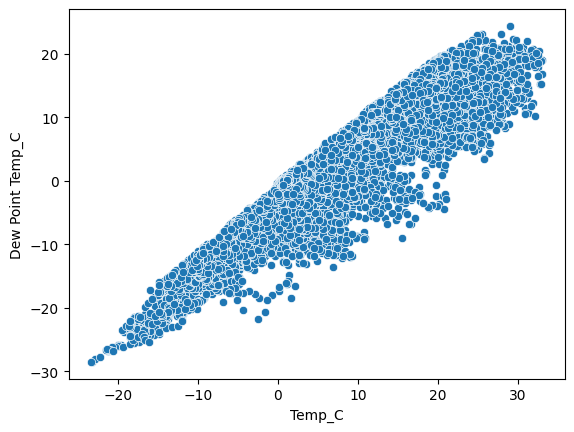

In [33]:
sns.scatterplot(x='Temp_C',y='Dew Point Temp_C',data=weatherData)

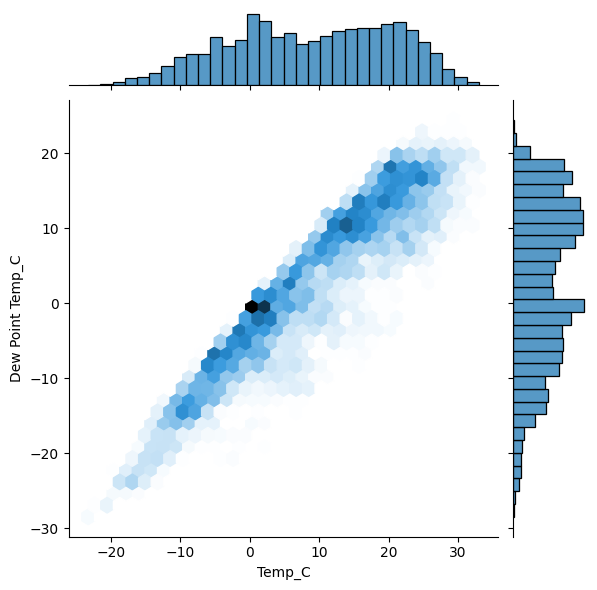

In [35]:
sns.jointplot(x='Temp_C',y='Dew Point Temp_C',data=weatherData,kind='hex')

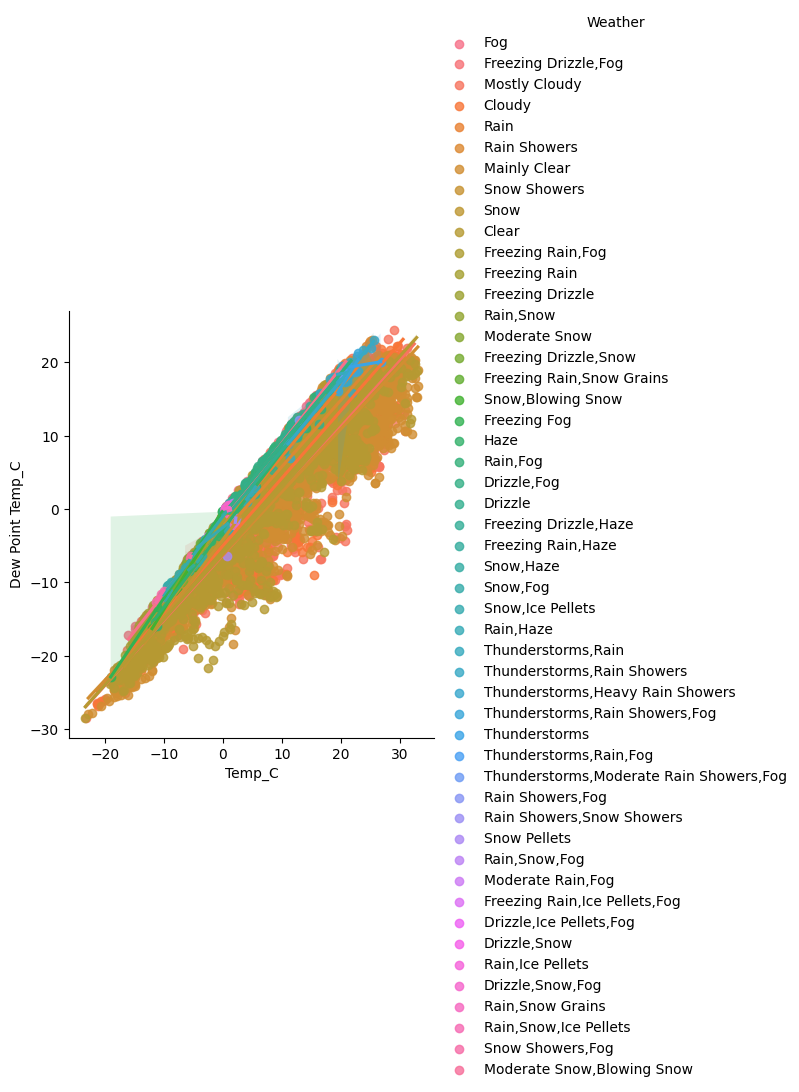

In [37]:
sns.lmplot(x='Temp_C',y='Dew Point Temp_C',data=weatherData,hue='Weather')

/tmp/ipykernel_2840/2365462436.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(weatherData['Temp_C'])


<Axes: xlabel='Temp_C', ylabel='Density'>

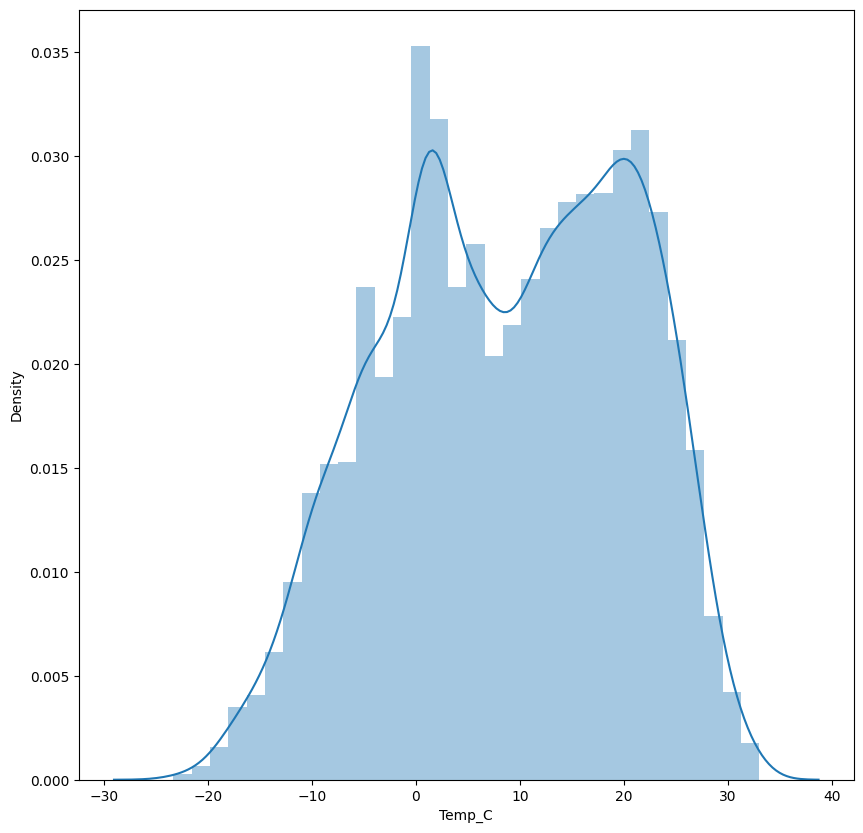

In [39]:
plt.figure(figsize=(10,10))
plt.tight_layout()
sns.distplot(weatherData['Temp_C'])

<Axes: >

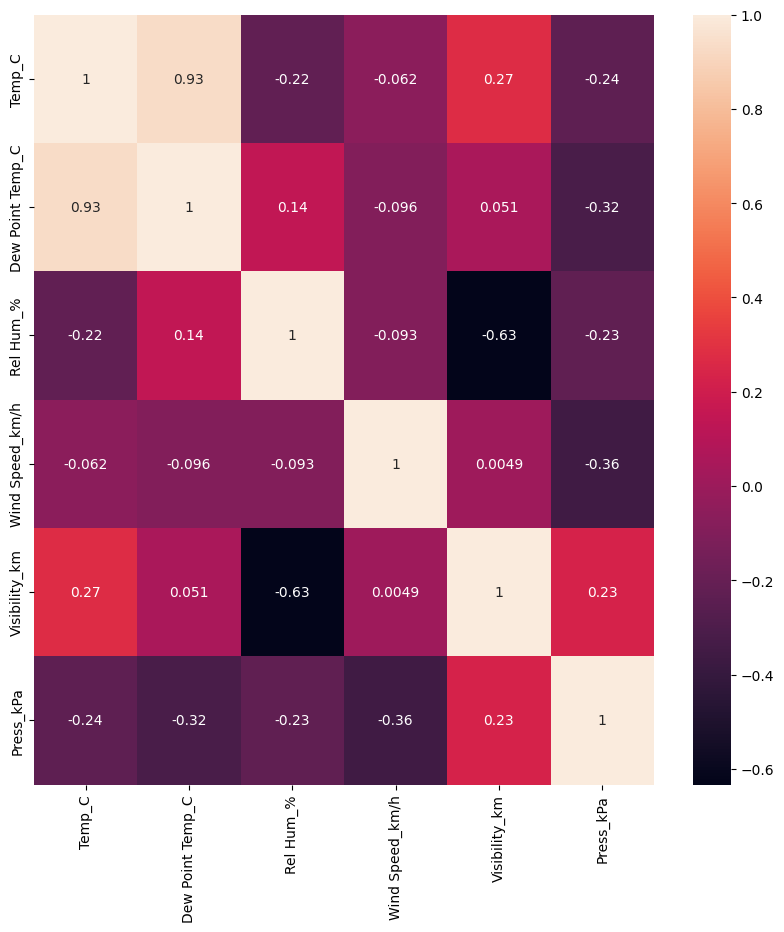

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,10))
plt.tight_layout()
sns.heatmap(weatherData.select_dtypes(include=['number']).corr(),annot=True)

In [43]:
X_Prediction = weatherData[['Rel Hum_%']]
print(X_Prediction)

      Rel Hum_%
0            86
1            87
2            89
3            88
4            88
...         ...
8779         81
8780         83
8781         93
8782         89
8783         86

[8784 rows x 1 columns]


In [45]:
y_test = weatherData['Temp_C']
print(y_test)

0      -1.8
1      -1.8
2      -1.8
3      -1.5
4      -1.5
       ... 
8779    0.1
8780    0.2
8781   -0.5
8782   -0.2
8783    0.0
Name: Temp_C, Length: 8784, dtype: float64


In [47]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_Prediction, y_test)
temperaturePredictions = model.predict(X_Prediction)

In [48]:
temperaturePredictions

array([5.97379676, 5.82169093, 5.51747927, ..., 4.90905595, 5.51747927,
       5.97379676])

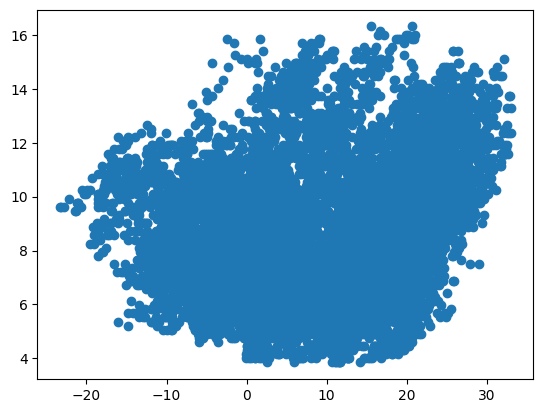

In [50]:
plt.scatter(y_test,temperaturePredictions)

/tmp/ipykernel_2840/1446496936.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test-temperaturePredictions)


<Axes: xlabel='Temp_C', ylabel='Density'>

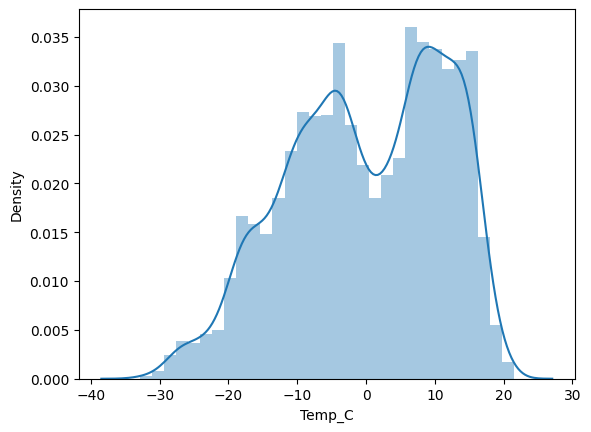

In [51]:
sns.distplot(y_test-temperaturePredictions)

In [52]:
from sklearn import metrics
metrics.mean_absolute_error(y_test,temperaturePredictions)

9.777772673617818

In [53]:
metrics.mean_squared_error(y_test,temperaturePredictions)

129.96910686335994

In [54]:
numpyInstace.sqrt(metrics.mean_squared_error(y_test,temperaturePredictions))

np.float64(11.40039941683448)

In [56]:
print('Coefficients:', model.coef_)
print('Intercept:', model.intercept_)

Coefficients: [-0.15210583]
Intercept: 19.054898121641642
